# ЛАБОРАТОРНАЯ РАБОТА № 2

**Тема**: Предобработка данных, построение модели машинного обучения для задачи бинарной классификации.

**Постановка**: Провести предобработку данных. Разработать и оценить классификатор, прогнозирующий вероятность прекращения сотрудничества клиента с банком.

**Цель**: Получить оценку не ниже 0.59 на метрике F1-score.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

### Установим красивые дефолтные настройки
### Может быть лень постоянно прописывать
### У графиков параметры цвета, размера, шрифта
### Можно положить их в словарь дефолтных настроек

import matplotlib as mlp

mlp.rcParams['lines.linewidth'] = 5
mlp.rcParams['xtick.major.size'] = 20
mlp.rcParams['xtick.major.width'] = 5
mlp.rcParams['xtick.labelsize'] = 20
mlp.rcParams['xtick.color'] = '#FF5533'

mlp.rcParams['ytick.major.size'] = 20
mlp.rcParams['ytick.major.width'] = 5
mlp.rcParams['ytick.labelsize'] = 20
mlp.rcParams['ytick.color'] = '#FF5533'

mlp.rcParams['axes.labelsize'] = 20
mlp.rcParams['axes.titlesize'] = 20
mlp.rcParams['axes.titlecolor'] = '#00B050'
mlp.rcParams['axes.labelcolor'] = '#00B050'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

### Прочитаем табличку для 2 лабы
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2 лаба/Bank_data.csv')

data.head(20)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8.0,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7.0,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4.0,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4.0,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2.0,134603.88,1,1,1,71725.73,0


## Знакомство с данными
Какие типы данных и их формат


In [ ]:
data.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,float64
Balance,float64
NumOfProducts,int64


<dl>
<dt> Описание колонок:
<dd> Number — индекс строки в данных  </dd>
<dd> CustomerId — уникальный идентификатор клиента </dd>
<dd> Surname — фамилия </dd>
<dd> CreditScore — кредитный рейтинг  </dd>
<dd> Geography — страна проживания </dd>
<dd> Gender — пол </dd>
<dd> Age — возраст </dd>
<dd> Tenure — сколько лет человек является клиентом банка </dd>
<dd> Balance — баланс на счёте </dd>
<dd> NumOfProducts — количество продуктов банка, используемых клиентом </dd>
<dd> HasCrCard — наличие кредитной карты </dd>
<dd> IsActiveMember — активность клиента </dd>
<dd> EstimatedSalary — предполагаемая зарплата </dd>
<dd> Exited — факт ухода клиента </dd>

</dl>










In [ ]:
### Проверка на дубликаты
data.duplicated().sum()

np.int64(0)

Колонку индекса строки можно перевести в индекс датасета, либо удалить, id и фамилии тоже не несут никакой логики, можно удалить

In [ ]:
### удаляем useless
data = data.drop(['RowNumber','CustomerId', 'Surname' ], axis=1)

In [ ]:
print(f'Всего колонок: {data.shape[1]}')
print(f'Всего данных (строк): {len(data)}')

Всего колонок: 11
Всего данных (строк): 10000


In [ ]:
data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,9091.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,4.997690,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.894723,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,2.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
data.describe(include='object')

,Geography,Gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


По первому впечатлению делаю вывод, что пропуски есть только в колонке **Tenure**, то есть сколько лет клиент в банке.
Половина клиентов из Франции, причем всего 2 гендера, меня это устраивает:)
Следующим шагом будет заполнение пропусков.

In [ ]:
### проверим количество пропусков в каждой из колонок, а также число их уникальных значений
missing_values = data.isna().sum()
if missing_values.sum() > 0:
    print('Есть пропуски:')
    columns_with_missing = missing_values[missing_values > 0]
    print(columns_with_missing)

    print('\nКоличество уникальных значений для колонок с пропусками:')
    for col in columns_with_missing.index:
        unique_count = data[col].nunique()
        print(f'{col}: {unique_count} уникальных значений')

    print('\nНет пропусков у колонок:')
    columns_without_missing = missing_values[missing_values == 0].index.tolist()
    print(columns_without_missing)
else:
    print('Пропусков нет')

print(f'\nВсего строк: {data.shape[0]}')

Есть пропуски:
Tenure    909
dtype: int64

Количество уникальных значений для колонок с пропусками:
Tenure: 11 уникальных значений

Нет пропусков у колонок:
['CreditScore', 'Geography', 'Gender', 'Age', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Всего строк: 10000


In [ ]:
### Посмотрим, какие уникальные значения есть в колонке с пропусками
data['Tenure'].value_counts()

,count
Tenure,
1.0,952
2.0,950
8.0,933
3.0,928
5.0,927
7.0,925
4.0,885
9.0,882
6.0,881


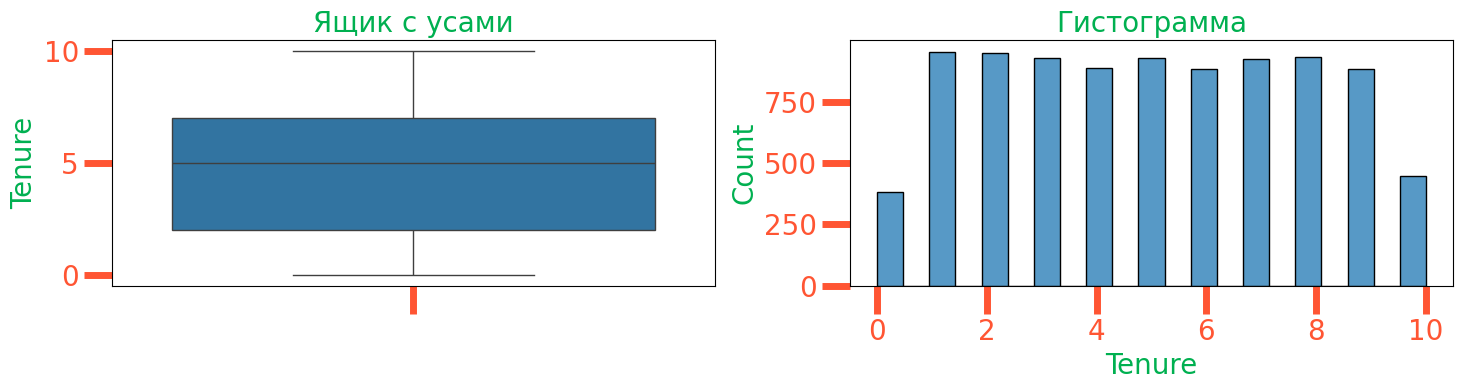

In [ ]:
### Посмотрим на ящик с усами и гистограмму это колонки
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Ящик с усами
sns.boxplot(data=data, y='Tenure', ax=axes[0])
axes[0].set_title('Ящик с усами')

# Гистограмма
sns.histplot(data['Tenure'], ax=axes[1])
axes[1].set_title('Гистограмма')

plt.tight_layout()
plt.show()

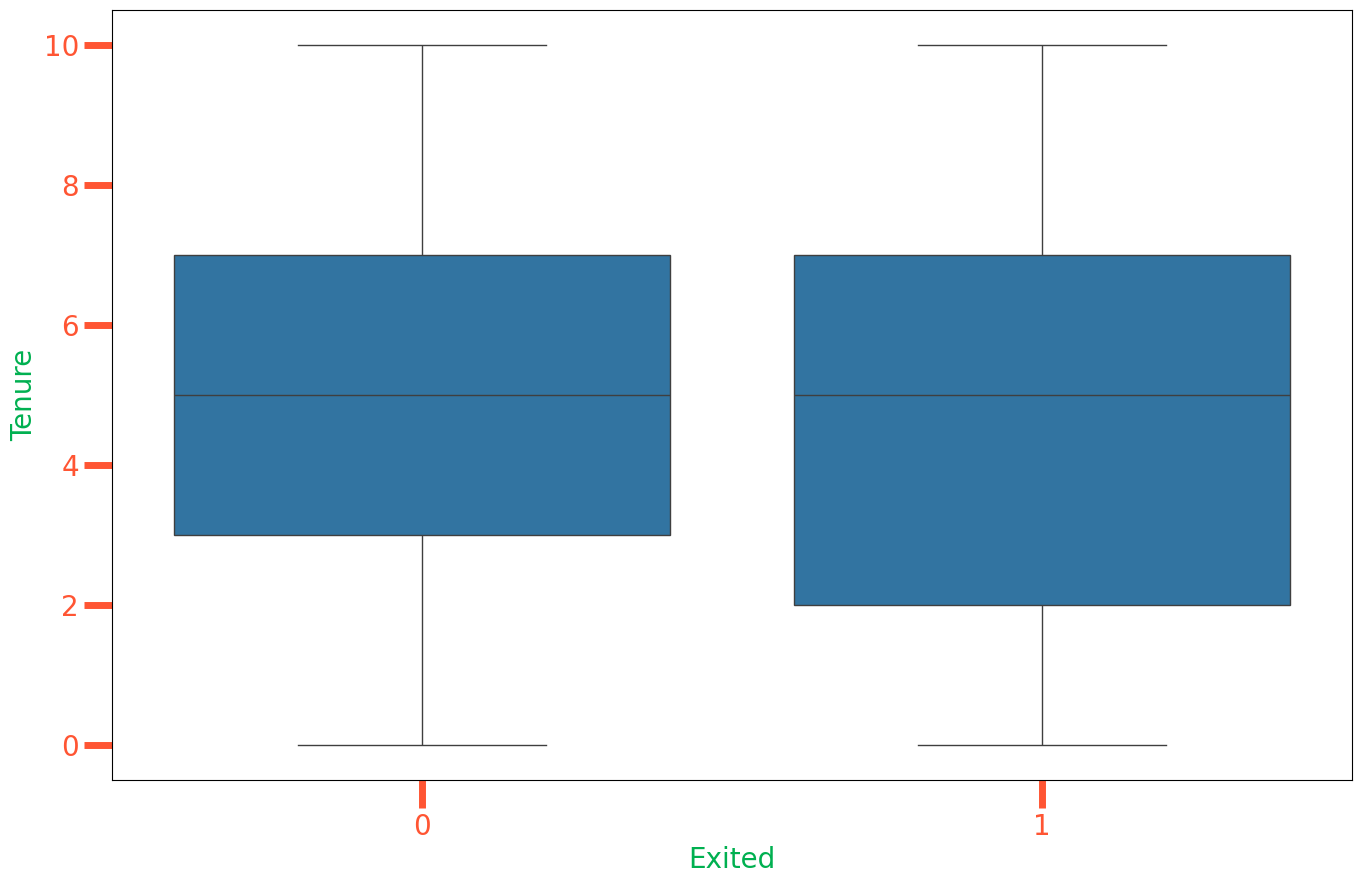

In [ ]:
### Подсмотрим в таргет
fig = plt.figure()
fig.set_size_inches(16, 10)

sns.boxplot(y='Tenure', x=data['Exited'].astype('category'), data=data)
plt.show()


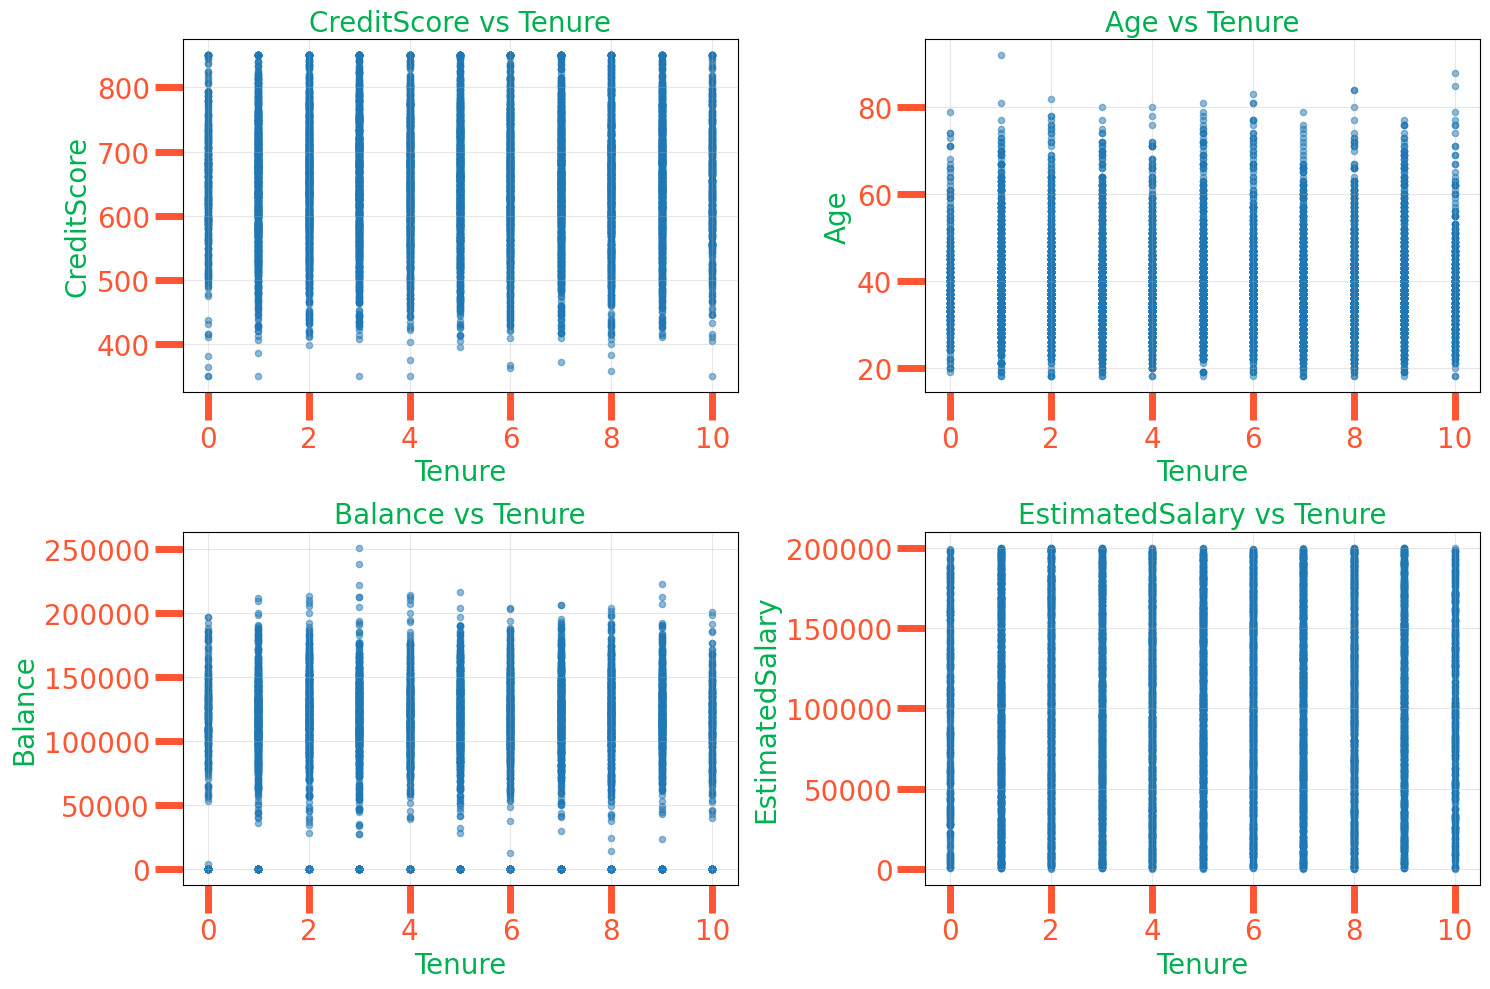

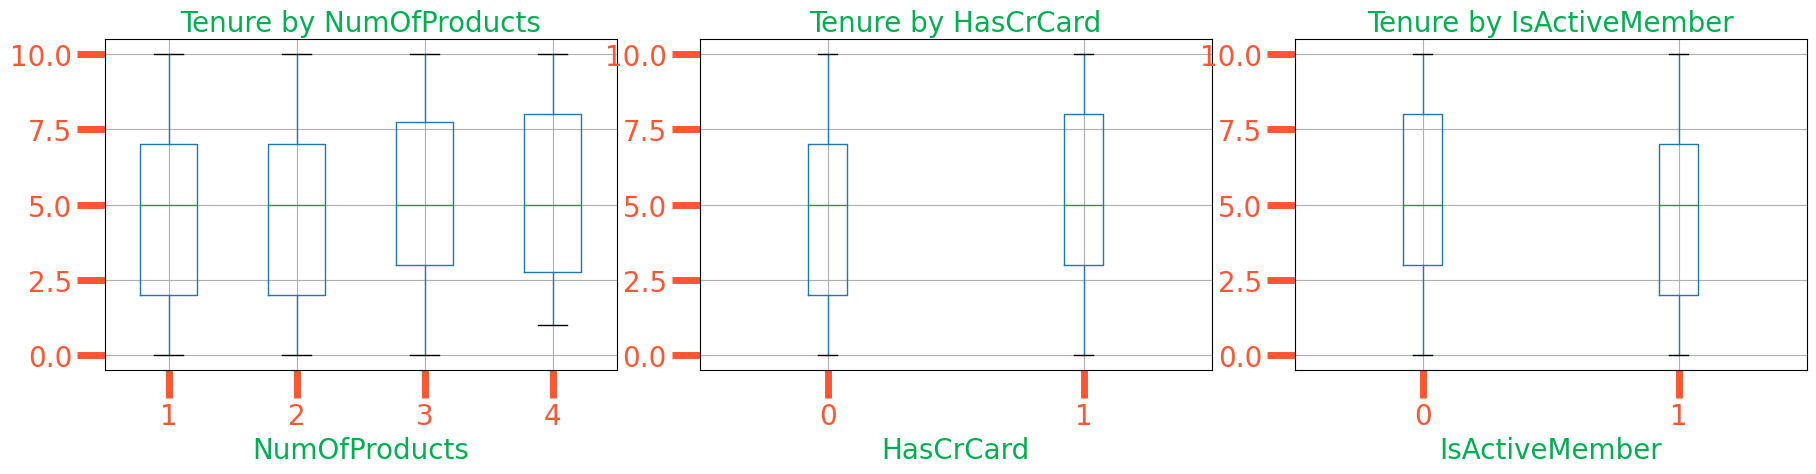

In [ ]:
# Графики для числовых колонок
numeric_columns_2 = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_columns_2):
    axes[i].scatter(data['Tenure'], data[col], alpha=0.5, s=20)
    axes[i].set_xlabel('Tenure')
    axes[i].set_ylabel(col)
    axes[i].set_title(f'{col} vs Tenure')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Графики для категориальных колонок
as_category = ['NumOfProducts', 'HasCrCard', 'IsActiveMember']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(as_category):
    # Boxplot для категориальных признаков
    data.boxplot(column='Tenure', by=col, ax=axes[i])
    axes[i].set_title(f'Tenure by {col}')
    axes[i].set_xlabel(col)

plt.suptitle('')  # Убираем общий заголовок
plt.tight_layout()
plt.show()

После долгого анализа по колонке **Tenure** не могу сказать конкретно, чем лучше заполнить пропуски, ни от чего он не зависит, после, в матрице корреляций это будет подтверждено, поэтому заполню через метод KNN, так как датасет небольшой, тяжело не будет, но он все равно средним заполнит почти все пропуски

In [ ]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
data['Tenure'] = imputer.fit_transform(data[['Tenure']])[:, 0].round()
print(f"Пропусков осталось: {data['Tenure'].isna().sum()}")

Пропусков осталось: 0


In [ ]:
### отберем числовые колонки, без булевых и категориальных
numeric_columns = data.loc[:, data.dtypes !=object].columns.drop(['Exited','NumOfProducts', 'HasCrCard','IsActiveMember'])
numeric_columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary'], dtype='object')

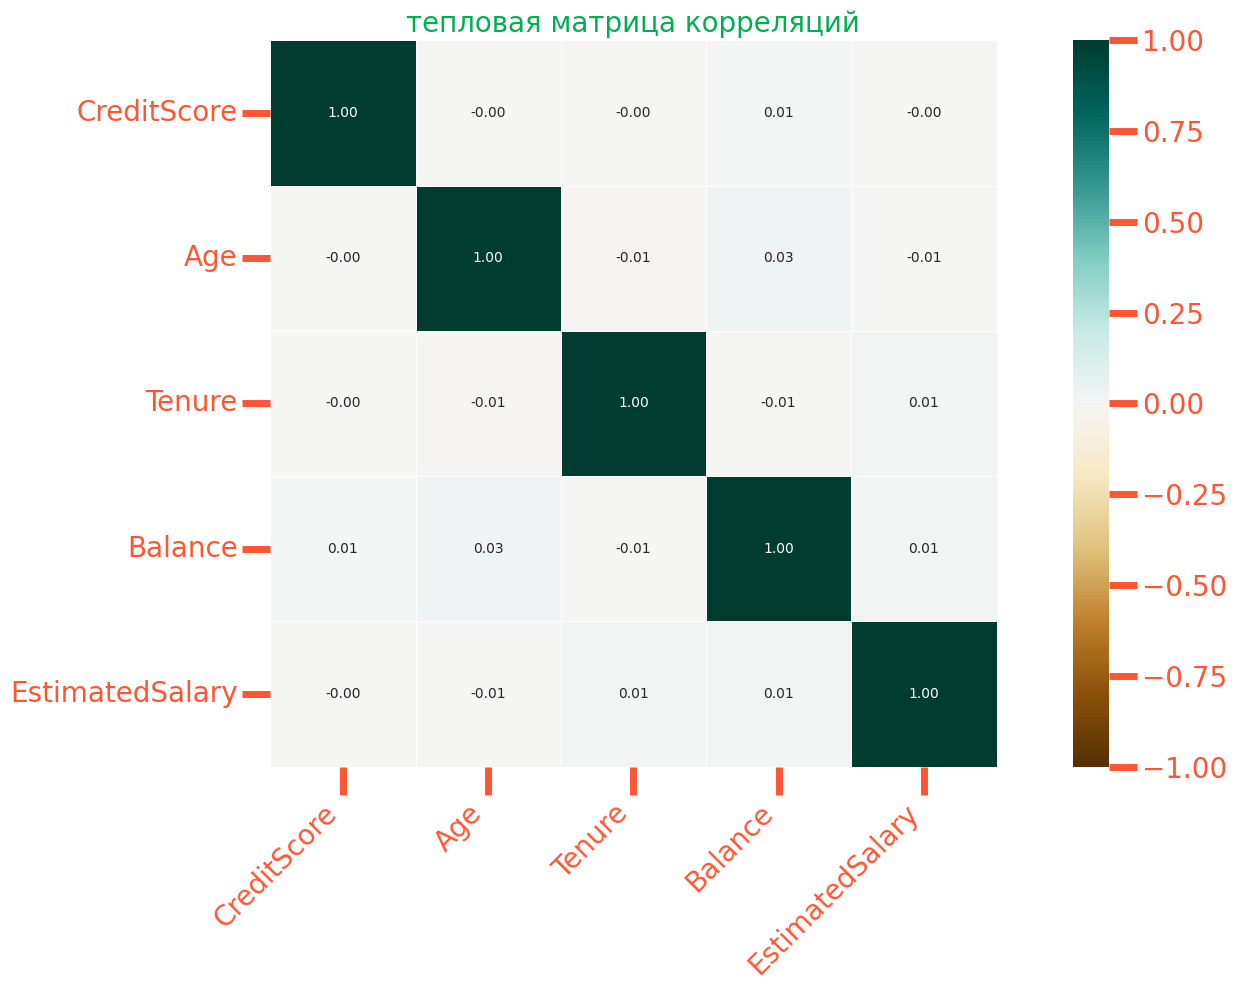

In [ ]:
### нарисуем тепловую карту корреляций
import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure()

fig.set_size_inches(16, 10)

sns.heatmap(data[numeric_columns].corr(),
            xticklabels=numeric_columns,
            yticklabels=numeric_columns,
            cmap='BrBG',
            vmin=-1,
            vmax=1,
            annot=True,
            fmt='.2f',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('тепловая матрица корреляций')
plt.xticks(rotation=45, ha='right')
plt.yticks()
plt.tight_layout()
plt.show()


Корреляции какие-либо отсутствуют.
Проведем некоторые операции по компановке колонок, вдруг потом понадобится.

In [ ]:
data['IsActiveMember'] = data['IsActiveMember'].astype('bool')
data['HasCrCard'] = data['HasCrCard'].astype('bool')
data['NumOfProducts'] = data['NumOfProducts'].astype('category')

# Категориальные колонки
categorical_columns = data.select_dtypes(include=['object', 'category']).columns
print("Категориальные:", list(categorical_columns))

# Бинарные колонки
binary_columns = data.select_dtypes(include=['bool']).columns
print("Бинарные:", list(binary_columns))

Категориальные: ['Geography', 'Gender', 'NumOfProducts']
Бинарные: ['HasCrCard', 'IsActiveMember']


## Удаление выбросов

In [ ]:
print(f'количество дубликатов: {data.duplicated().sum()}')

количество дубликатов: 0


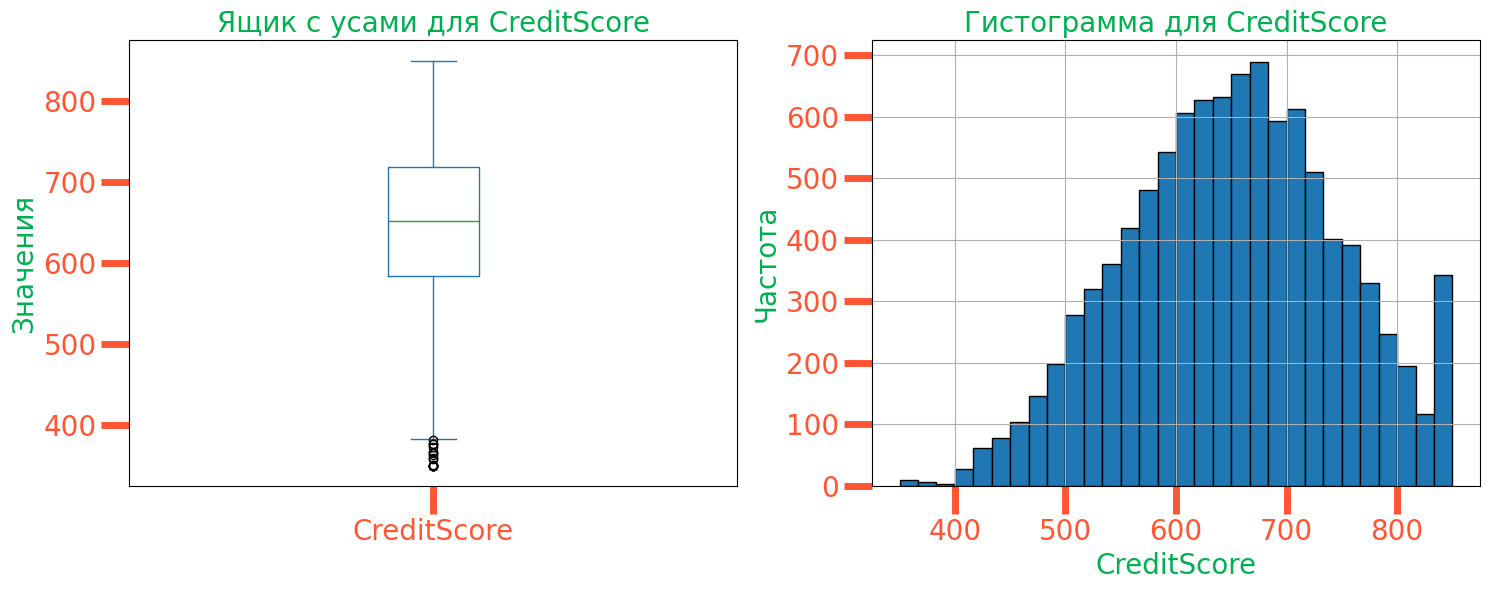

Информация по CreditScore:
MIN: 350.00
Q1: 584.00
Медиана: 652.00
Q3: 718.00
MAX: 850.00
IQR: 134.00
Границы выбросов: [383.00, 919.00]
Выбросы слева (< 383.00): 15 штук
Выбросы справа (> 919.00): 0 штук
Всего выбросов: 15 штук
Процент выбросов: 0.15%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


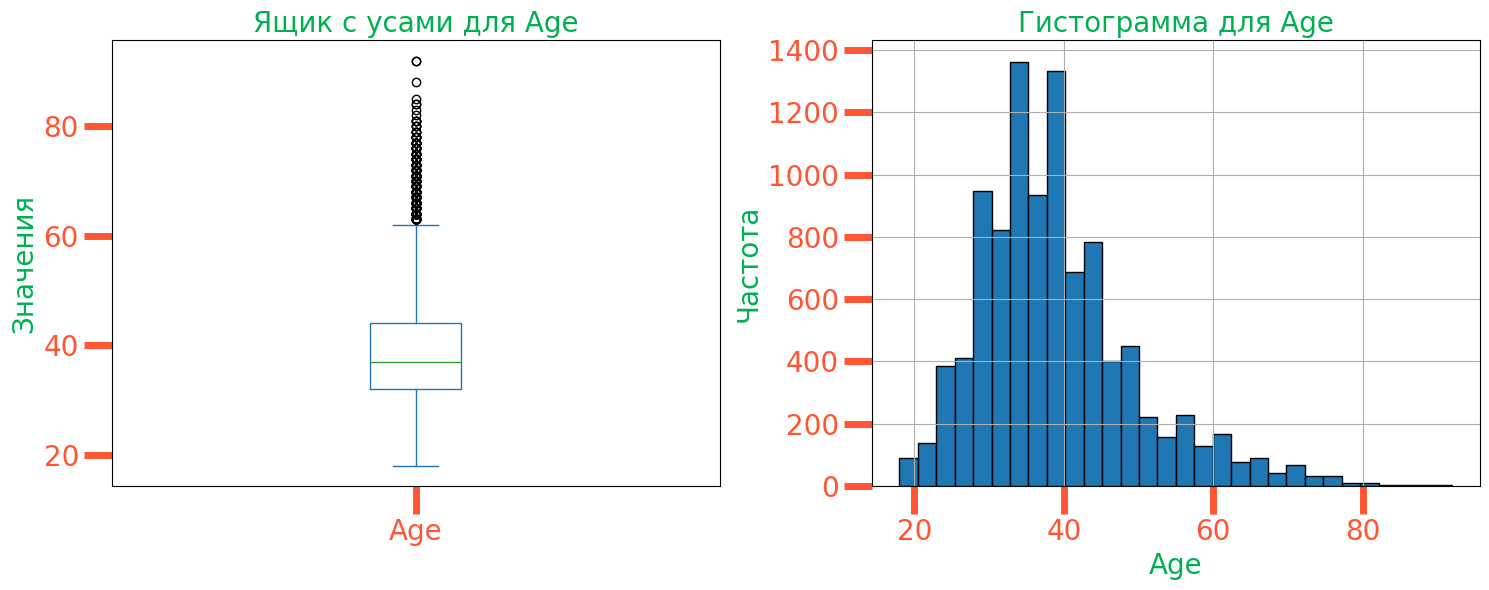

Информация по Age:
MIN: 18.00
Q1: 32.00
Медиана: 37.00
Q3: 44.00
MAX: 92.00
IQR: 12.00
Границы выбросов: [14.00, 62.00]
Выбросы слева (< 14.00): 0 штук
Выбросы справа (> 62.00): 359 штук
Всего выбросов: 359 штук
Процент выбросов: 3.59%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


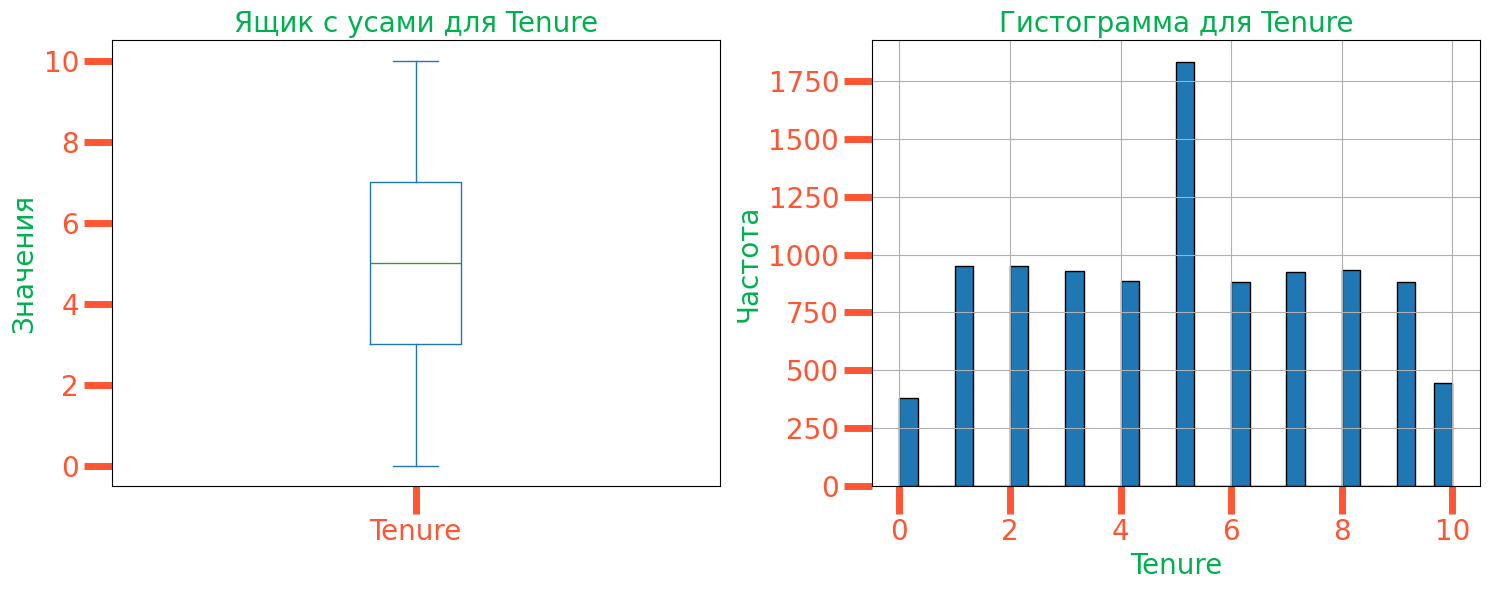

Информация по Tenure:
MIN: 0.00
Q1: 3.00
Медиана: 5.00
Q3: 7.00
MAX: 10.00
IQR: 4.00
Границы выбросов: [-3.00, 13.00]
Выбросы слева (< -3.00): 0 штук
Выбросы справа (> 13.00): 0 штук
Всего выбросов: 0 штук
Процент выбросов: 0.00%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


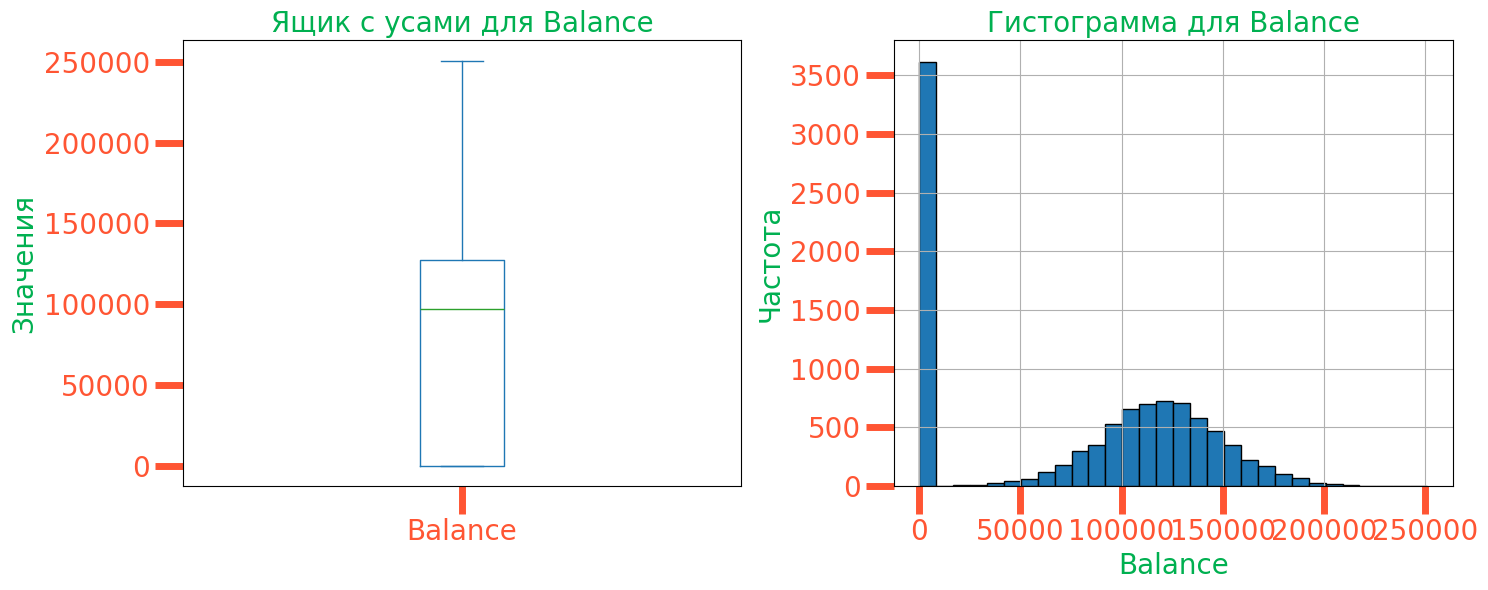

Информация по Balance:
MIN: 0.00
Q1: 0.00
Медиана: 97198.54
Q3: 127644.24
MAX: 250898.09
IQR: 127644.24
Границы выбросов: [-191466.36, 319110.60]
Выбросы слева (< -191466.36): 0 штук
Выбросы справа (> 319110.60): 0 штук
Всего выбросов: 0 штук
Процент выбросов: 0.00%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


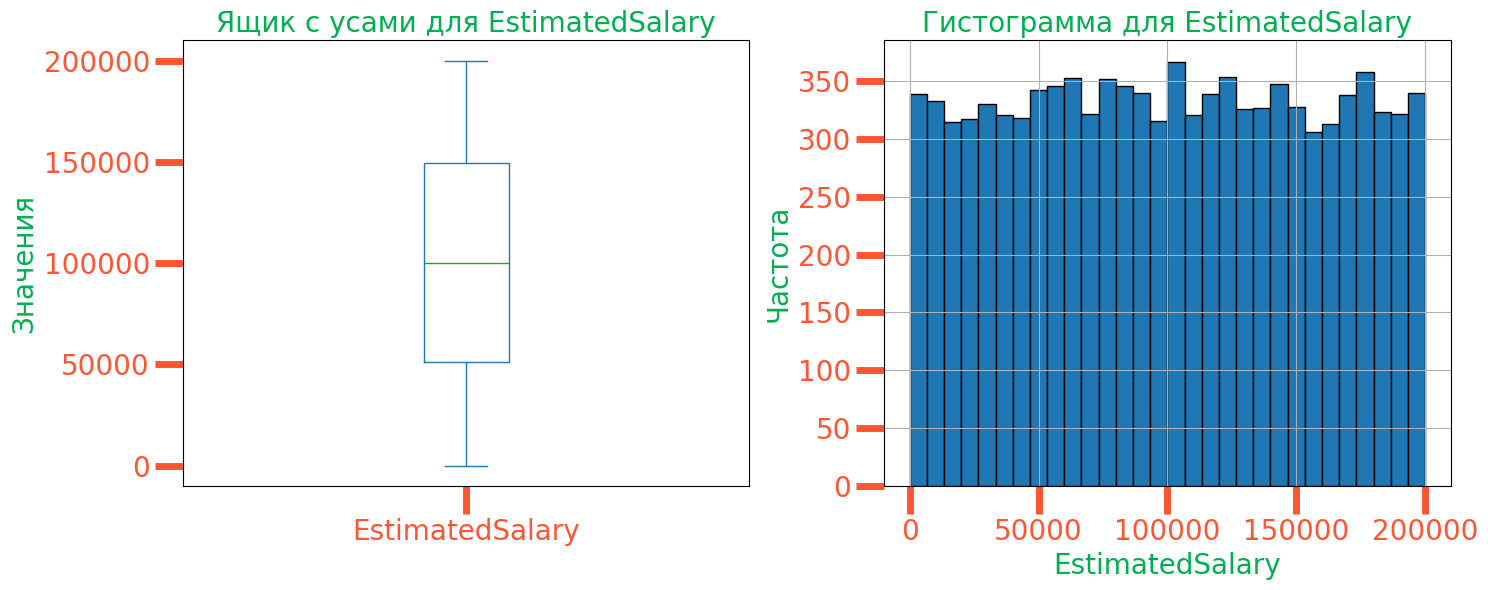

Информация по EstimatedSalary:
MIN: 11.58
Q1: 51002.11
Медиана: 100193.91
Q3: 149388.25
MAX: 199992.48
IQR: 98386.14
Границы выбросов: [-96577.10, 296967.45]
Выбросы слева (< -96577.10): 0 штук
Выбросы справа (> 296967.45): 0 штук
Всего выбросов: 0 штук
Процент выбросов: 0.00%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
### для числовых колонок посторим гистограммы и ящики с усами со всякой статистикой
for column in numeric_columns:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

  # Ящик с усами
  data[column].plot(kind='box', ax=ax1)
  ax1.set_title(f'Ящик с усами для {column}')
  ax1.set_ylabel('Значения')

  # Гистограмма
  data[column].hist(bins=30, ax=ax2, edgecolor='black')
  ax2.set_title(f'Гистограмма для {column}')
  ax2.set_xlabel(column)
  ax2.set_ylabel('Частота')

  plt.tight_layout()
  plt.show()

  # Статистика (остается без изменений)
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  out_low = data[data[column] < lower_bound]
  out_high = data[data[column] > upper_bound]

  print(f"Информация по {column}:")
  print(f"MIN: {data[column].min():.2f}")
  print(f"Q1: {Q1:.2f}")
  print(f"Медиана: {data[column].median():.2f}")
  print(f"Q3: {Q3:.2f}")
  print(f"MAX: {data[column].max():.2f}")
  print(f"IQR: {IQR:.2f}")
  print(f"Границы выбросов: [{lower_bound:.2f}, {upper_bound:.2f}]")
  print(f"Выбросы слева (< {lower_bound:.2f}): {len(out_low)} штук")
  print(f"Выбросы справа (> {upper_bound:.2f}): {len(out_high)} штук")
  print(f"Всего выбросов: {len(out_low) + len(out_high)} штук")
  print(f"Процент выбросов: {(len(out_low) + len(out_high)) / len(data) * 100:.2f}%")
  print("-" * 200)


Выбросы для числовых колонок:
1. Для кредитного рэйтинга: выбросы удалять не будем, это вполне реальные значения проблемных клиентов
2. Для колонки возраста: нет аномалий, пожилые клиенты имеют право на жизнь, но возможно следует содать возрастные группы
3. Для tenure оставляем как есть
4. Баланс вполне реален, но много людей с нулевым балансом, это может нарушить логику модели: можно создать признаки с категориями баланса
5. Для ожидаемой зарплаты оставим как есть

In [ ]:
### посмотрим на значения в категориальных

for col in categorical_columns:
  print(f"\n--- {col} ---")
  print(data[col].value_counts())


--- Geography ---
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

--- Gender ---
Gender
Male      5457
Female    4543
Name: count, dtype: int64

--- NumOfProducts ---
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


In [ ]:
### сделаем OHE для категориальных, у них немного уникальных значений
for col in categorical_columns:
  one_hot = pd.get_dummies(data[col], prefix=col, drop_first=True)
  data = pd.concat((data.drop(col, axis=1), one_hot), axis=1)
data.head()

,CreditScore,Age,Tenure,Balance,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,NumOfProducts_2,NumOfProducts_3,NumOfProducts_4
0,619,42,2.0,0.00,True,True,101348.88,1,False,False,False,False,False,False
1,608,41,1.0,83807.86,False,True,112542.58,0,False,True,False,False,False,False
2,502,42,8.0,159660.80,True,False,113931.57,1,False,False,False,False,True,False
3,699,39,1.0,0.00,False,False,93826.63,0,False,False,False,True,False,False
4,850,43,2.0,125510.82,True,True,79084.10,0,False,True,False,False,False,False


## Анализ распределения таргета


Exited
0    7963
1    2037
Name: count, dtype: int64
Ушло клиентов: 20.4%


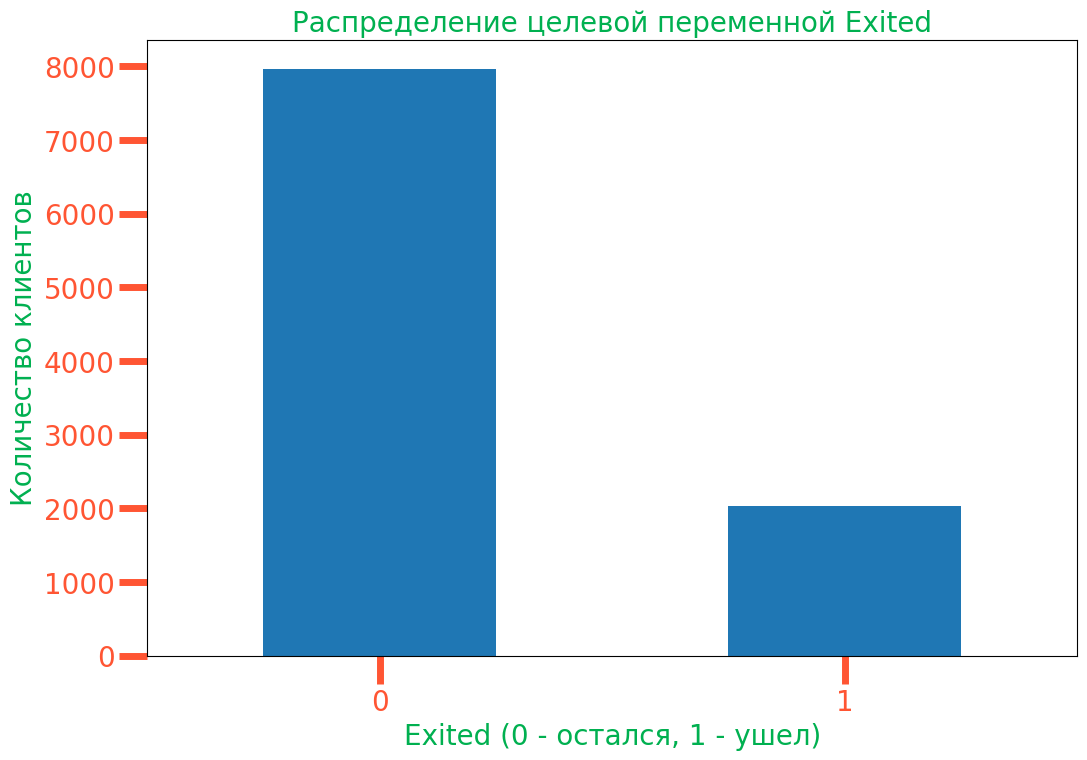

In [ ]:
# Распределение таргета
target_counts = data['Exited'].value_counts()
print(target_counts)
print(f"Ушло клиентов: {target_counts[1]/len(data)*100:.1f}%")

plt.figure(figsize=(12, 8))
data['Exited'].value_counts().plot(kind='bar')
plt.title('Распределение целевой переменной Exited')
plt.xlabel('Exited (0 - остался, 1 - ушел)')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=0)
plt.show()



Баланс 80 к 20, присутствует дисбаланс

## ОБУЧЕНИЕ МОДЕЛИ

In [ ]:
### Разделим данные на признаки и таргет

X=data.drop('Exited', axis=1)
y=data['Exited']

In [ ]:
### Разобьем на тренировочные и тестовые данные
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test  = train_test_split(X, y,
                                                     test_size=0.2,
                                                     shuffle=True,
                                                     random_state=2022)

In [ ]:
### Запишем первый pipeline с логистической регрессией без каких-либо операций
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report


pipe_dis = Pipeline([('scaler', StandardScaler()),
                     ('LR', LogisticRegression())])

pipe_dis.fit(X_train, y_train)

y_pred_lr_dis = pipe_dis.predict(X_test)
print(classification_report(y_test, y_pred_lr_dis, digits=3))


              precision    recall  f1-score   support

           0      0.851     0.971     0.907      1587
           1      0.757     0.346     0.475       413

    accuracy                          0.842      2000
   macro avg      0.804     0.659     0.691      2000
weighted avg      0.831     0.842     0.818      2000



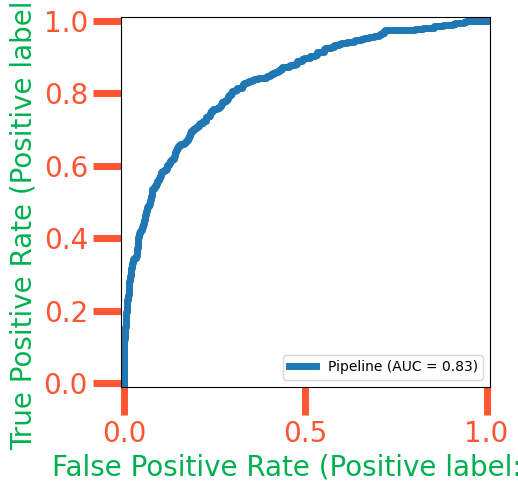

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(pipe_dis, X_test, y_test)

После обучения моделью логистической регресии без указания четких параметров может показаться, что были получены неплохие показатели, но важно понимать, что если бы мы просто для всех клиентов предсказывали в тупую значение 0, то мы получили accuracy, равное 80, неплохо, если не вдаваться в подробности, что для класса 1 мы почти 65% уходящих клиентов не замечаем, так как у нас recall=0.35, который характеризует, какую долю из всех клиентов 1 класса, мы угадываем


In [ ]:
### попробуем поиграться с параметрами
from sklearn.model_selection import GridSearchCV

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('LR', LogisticRegression())
])

param_grid = {
    'LR__C': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'LR__penalty': ['l1', 'l2', 'elasticnet']
}

grid_search_lr = GridSearchCV(
    pipe_lr,
    param_grid,
    cv=5,
    scoring='f1'
)

grid_search_lr.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search_lr.best_params_}")

# Предсказание лучшей моделью
y_pred_lr = grid_search_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr, digits=3))

Лучшие параметры: {'LR__C': 1, 'LR__penalty': 'l2'}
              precision    recall  f1-score   support

           0      0.851     0.971     0.907      1587
           1      0.757     0.346     0.475       413

    accuracy                          0.842      2000
   macro avg      0.804     0.659     0.691      2000
weighted avg      0.831     0.842     0.818      2000



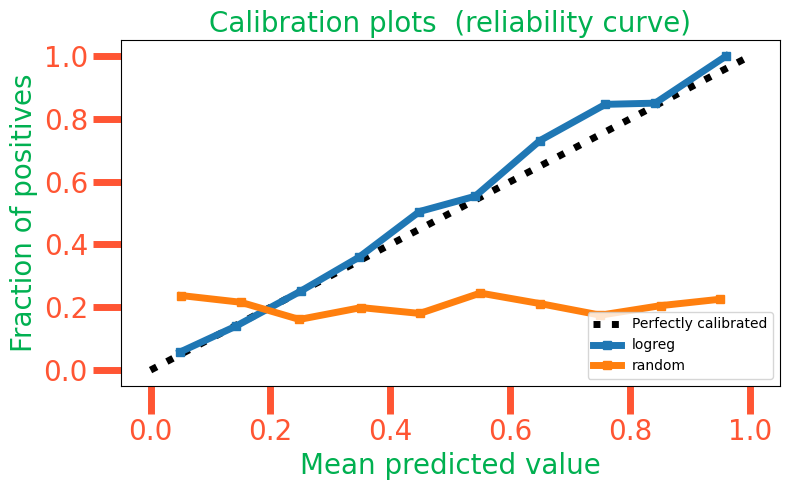

In [ ]:
### Нарисую калибровочную кривую
from sklearn.calibration import calibration_curve
import numpy as np

plt.figure(figsize=(8, 5))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

### Предсказания модели на тесте и соответствующая калибровочная кривая
prob_pos = grid_search_lr.predict_proba(X_test)[:, 1]
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, prob_pos, n_bins=10)
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="logreg")

### Пусть наши предсказания - случайные, то есть для каждого объекта
### вероятность принадлежности + классу это просто случайное число [0; 1]
prob_pos = np.random.uniform(size=(X_test.shape[0],))
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, prob_pos, n_bins=10)
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="random")

plt.ylabel("Fraction of positives")
plt.xlabel("Mean predicted value")
plt.ylim([-0.05, 1.05])
plt.legend(loc="lower right")
plt.title('Calibration plots  (reliability curve)')
plt.tight_layout()

## УЧЕТ ДИСБАЛАНСА

In [ ]:
### LOGISTIC REGRESSION C oversampling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

pipe_lr_over = Pipeline([('scaler', StandardScaler()),
                    ('smote', SMOTE(random_state=42)),
                    ('lr', LogisticRegression())])

param_lr_over = {
    'smote__sampling_strategy': [0.3, 0.5, 0.7, 1.0],
    'lr__C': [0.001, 0.01, 0.1, 1, 10],
    'lr__penalty': ['l1', 'l2', 'elasticnet']
}

gridsearch_lr_over = GridSearchCV(
    pipe_lr_over,
    param_lr_over,
    cv=5,
    scoring='f1'
)

gridsearch_lr_over.fit(X_train, y_train)

print(f"Лучшие параметры: {gridsearch_lr_over.best_params_}")

# Предсказание лучшей моделью
y_pred_lr_over = gridsearch_lr_over.predict(X_test)
print(classification_report(y_test, y_pred_lr_over, digits=3))

Лучшие параметры: {'lr__C': 0.1, 'lr__penalty': 'l2', 'smote__sampling_strategy': 0.7}
              precision    recall  f1-score   support

           0      0.904     0.848     0.875      1587
           1      0.527     0.654     0.584       413

    accuracy                          0.807      2000
   macro avg      0.716     0.751     0.729      2000
weighted avg      0.826     0.807     0.815      2000



In [ ]:
### LOGISTIC REGRESSION C undersampling
from imblearn.under_sampling import RandomUnderSampler

pipe_lr_under = Pipeline([('scaler', StandardScaler()),
                    ('undersample', RandomUnderSampler(random_state=42)),
                    ('lr', LogisticRegression())])

param_lr_under = {
    'undersample__sampling_strategy': [0.3, 0.5, 0.7, 1.0],
    'lr__C': [0.001, 0.01, 0.1, 1, 10],
    'lr__penalty': ['l1', 'l2', 'elasticnet']
}

gridsearch_lr_under = GridSearchCV(
    pipe_lr_under,
    param_lr_under,
    cv=5,
    scoring='f1'
)

gridsearch_lr_under.fit(X_train, y_train)

print(f"Лучшие параметры: {gridsearch_lr_under.best_params_}")

# Предсказание лучшей моделью
y_pred_lr_under = gridsearch_lr_under.predict(X_test)
print(classification_report(y_test, y_pred_lr_under, digits=3))

Лучшие параметры: {'lr__C': 1, 'lr__penalty': 'l2', 'undersample__sampling_strategy': 0.7}
              precision    recall  f1-score   support

           0      0.904     0.848     0.875      1587
           1      0.527     0.654     0.584       413

    accuracy                          0.807      2000
   macro avg      0.716     0.751     0.729      2000
weighted avg      0.826     0.807     0.815      2000



In [ ]:
### DECISION TREE with oversampling
from sklearn.tree import DecisionTreeClassifier

pipe_tree_over = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('tree', DecisionTreeClassifier(random_state=42))
])

param_tree_over = {
    'smote__sampling_strategy': [0.3, 0.5, 0.7, 1.0],
    'tree__max_depth': [3, 5, 7, 10, 15],
    'tree__min_samples_split': [2, 5, 10],
    'tree__min_samples_leaf': [1, 2, 4],
    'tree__criterion': ['gini', 'entropy']
}

gridsearch_tree_over = GridSearchCV(
    pipe_tree_over,
    param_tree_over,
    cv=5,
    scoring='f1'
)

gridsearch_tree_over.fit(X_train, y_train)

print(f"Лучшие параметры: {gridsearch_tree_over.best_params_}")

# Предсказание лучшей моделью
y_pred_tree_over = gridsearch_tree_over.predict(X_test)
print(classification_report(y_test, y_pred_tree_over, digits=3))

Лучшие параметры: {'smote__sampling_strategy': 0.7, 'tree__criterion': 'entropy', 'tree__max_depth': 7, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
              precision    recall  f1-score   support

           0      0.901     0.882     0.891      1587
           1      0.581     0.627     0.603       413

    accuracy                          0.830      2000
   macro avg      0.741     0.755     0.747      2000
weighted avg      0.835     0.830     0.832      2000



In [ ]:
### RANDOM FOREST with oversampling
from sklearn.ensemble import RandomForestClassifier

pipe_rf_over = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

param_rf_over = {
    'smote__sampling_strategy': [0.3, 0.5, 0.7, 1.0],
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [5, 10, 15],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

gridsearch_rf_over = GridSearchCV(
    pipe_rf_over,
    param_rf_over,
    cv=5,
    scoring='f1'
)

gridsearch_rf_over.fit(X_train, y_train)

print(f"Лучшие параметры: {gridsearch_rf_over.best_params_}")

# Предсказание лучшей моделью
y_pred_rf_over = gridsearch_rf_over.predict(X_test)
print(classification_report(y_test, y_pred_rf_over, digits=3))

Лучшие параметры: {'rf__max_depth': 10, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 50, 'smote__sampling_strategy': 0.7}
              precision    recall  f1-score   support

           0      0.909     0.896     0.902      1587
           1      0.621     0.654     0.637       413

    accuracy                          0.846      2000
   macro avg      0.765     0.775     0.770      2000
weighted avg      0.849     0.846     0.847      2000



In [ ]:
### DecisionTreeClassifier c undersampling


pipe_tree_under = Pipeline([
    ('scaler', StandardScaler()),
    ('undersample', RandomUnderSampler(random_state=42)),
    ('tree', DecisionTreeClassifier(random_state=42))
])

param_tree_under = {
    'undersample__sampling_strategy': [0.3, 0.5, 0.7, 1.0],
    'tree__max_depth': [3, 5, 7, 10, 15],
    'tree__min_samples_split': [2, 5, 10],
    'tree__min_samples_leaf': [1, 2, 4],
    'tree__criterion': ['gini', 'entropy']
}

gridsearch_tree_under = GridSearchCV(
    pipe_tree_under,
    param_tree_under,
    cv=5,
    scoring='f1'
)

gridsearch_tree_under.fit(X_train, y_train)

print(f"Лучшие параметры: {gridsearch_tree_under.best_params_}")

# Предсказание лучшей моделью
y_pred_tree_under = gridsearch_tree_under.predict(X_test)
print(classification_report(y_test, y_pred_tree_under, digits=3))

Лучшие параметры: {'tree__criterion': 'gini', 'tree__max_depth': 5, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 5, 'undersample__sampling_strategy': 0.7}
              precision    recall  f1-score   support

           0      0.899     0.851     0.874      1587
           1      0.524     0.632     0.573       413

    accuracy                          0.805      2000
   macro avg      0.711     0.741     0.724      2000
weighted avg      0.821     0.805     0.812      2000



Обучил дерево решений c undersampling and oversampling, также рандомный лес на oversampling. По-хорошему можно было же не стандартизировать данные для деревьев, ведь они не чувствительны к масштабированию признаков, но хуже не должно быть, а запускать заново время жалко)
Сейчас сделаю красивую табличку в виде датафрейма, где будут f1-мера, точность и полнота для 1 класса объектов!

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


comparison_data = []

models = [
    ('Logistic Regression imbalance', grid_search_lr, y_pred_lr),
    ('Logistic Regression with oversampling', gridsearch_lr_over, y_pred_lr_over),
    ('Logistic Regression with undersampling', gridsearch_lr_under, y_pred_lr_under),
    ('DECISION TREE with oversampling', gridsearch_tree_over, y_pred_tree_over),
    ('RANDOM FOREST with oversampling', gridsearch_rf_over, y_pred_rf_over),
    ('DecisionTree with undersampling', gridsearch_tree_under, y_pred_tree_under)
]

for model_name, grid_search, y_pred in models:
    # Получаем вероятности для класса 1 для AUC-ROC
    y_pred_proba = grid_search.predict_proba(X_test)[:, 1]

    comparison_data.append({
        'Model': model_name,
        'CV F1-Score': round(grid_search.best_score_, 4),
        'Test Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Test Precision (class 1)': round(precision_score(y_test, y_pred), 4),
        'Test Recall (class 1)': round(recall_score(y_test, y_pred), 4),
        'Test F1-Score (class 1)': round(f1_score(y_test, y_pred), 4),
        'AUC-ROC': round(roc_auc_score(y_test, y_pred_proba), 4)
    })

comparison_data = pd.DataFrame(comparison_data)

comparison_data.sort_values('Test F1-Score (class 1)', ascending=False)

,Model,CV F1-Score,Test Accuracy,Test Precision (class 1),Test Recall (class 1),Test F1-Score (class 1),AUC-ROC
4,RANDOM FOREST with oversampling,0.6155,0.8460,0.6207,0.6538,0.6368,0.8592
3,DECISION TREE with oversampling,0.5868,0.8295,0.5807,0.6271,0.6030,0.8385
2,Logistic Regression with undersampling,0.5749,0.8075,0.5273,0.6538,0.5838,0.8353
1,Logistic Regression with oversampling,0.5703,0.8075,0.5273,0.6538,0.5838,0.8332
5,DecisionTree with undersampling,0.5781,0.8055,0.5241,0.6320,0.5730,0.8245
0,Logistic Regression imbalance,0.4945,0.8420,0.7566,0.3462,0.4751,0.8331


## Вывод
1. Лучшей моделью для учета дисбаланса стал случайный лес с применением метода oversamling (SMOTE), показав наибольшую f1-меру 1 класса для  объектов, предсказанных на тесте и кросс-валидации. Наибольший AUC-ROC также наблюдается для данной модели обучения.
2. Результаты борьбы с дисбалансом таргетной переменной с помощью двух техник балансировки Oversampling и Undersampling оказались эффективными, как и ожидалось.
3. Для данной предобработки данных более удачливым оказался подход oversampling, хотя важно отметить, что противоположный подход также дает улучшения на score, но на менее выраженные на доли.
4. Случайный лес - модель ансамблирования, более громоздкая и длительно-обучаемая в сравнении с той же логистической регресией, поэтому для каждой из бизнес задач необходимо взвешивать все за и против. Допустим, если разрешается жертвовать небольшим качеством ради быстроты выполнения задачи, то выбор может пасть и на модель логистической регресии.